# 1st phase: data acquisition & initial exploration

In [1]:
# Import essential libraries
import kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Authenticate
api = KaggleApi()
api.authenticate()

dataset = 'blastchar/telco-customer-churn'
file_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
# Define the dataset ID and the CSV filename inside the zip
dataset = 'blastchar/telco-customer-churn'
file_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Check if the file exists locally FIRST
if not os.path.exists(file_name):
    print("File not found. Downloading now (this will take a moment)...")
    # force=False means: "Only download if the file is missing"
    api.dataset_download_file(dataset, file_name=file_name, force=False)
    print("Download complete!")
else:
    print("File already exists. Skipping download completely!")

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_name)

# Start analyzing data
print(df.head())

File already exists. Skipping download completely!
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSuppo

In [3]:
# Shape of the dataset
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Data types and non‑null counts
df.info()

Dataset has 7043 rows and 21 columns.

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilli

In [4]:
# Summary Statistics for Numerical Columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Count of churn vs non‑churn
churn_counts = df["Churn"].value_counts()
print(churn_counts)

# Percentage
print(f"\nChurn rate: {churn_counts['Yes'] / len(df) * 100:.2f}%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


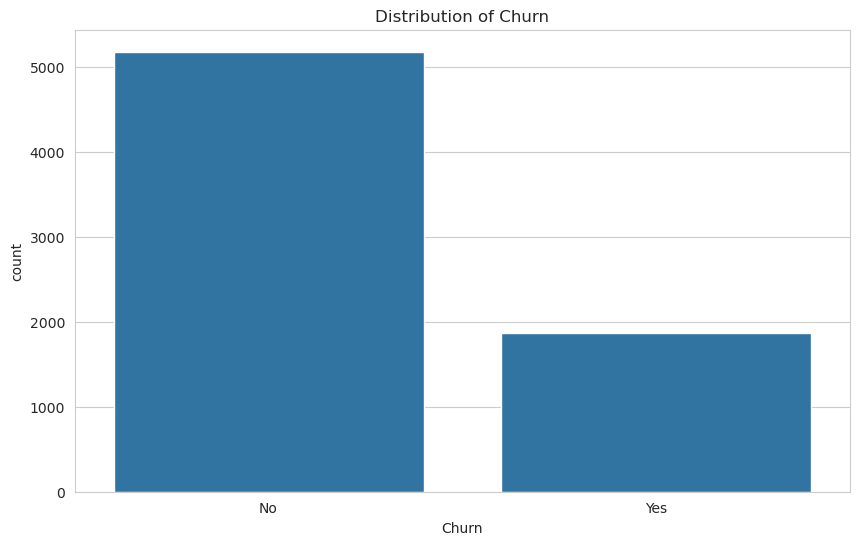

In [6]:
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Visualise
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.show()

In [7]:
# Identify categorical columns (object type)
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

# Safely exclude columns we don't want as features, even if they aren't in the list
exclude_cols = ["customerID", "Churn"]
cat_cols = [col for col in cat_cols if col not in exclude_cols]

# Numerical columns (int64, float64)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", cat_cols)
print("Numerical features:", num_cols)

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


# 2nd phase: EDA

## Visualization 1: Distribution of Numerical Features

**Question**: How are tenure, monthly charges, and total charges distributed? Are they skewed?

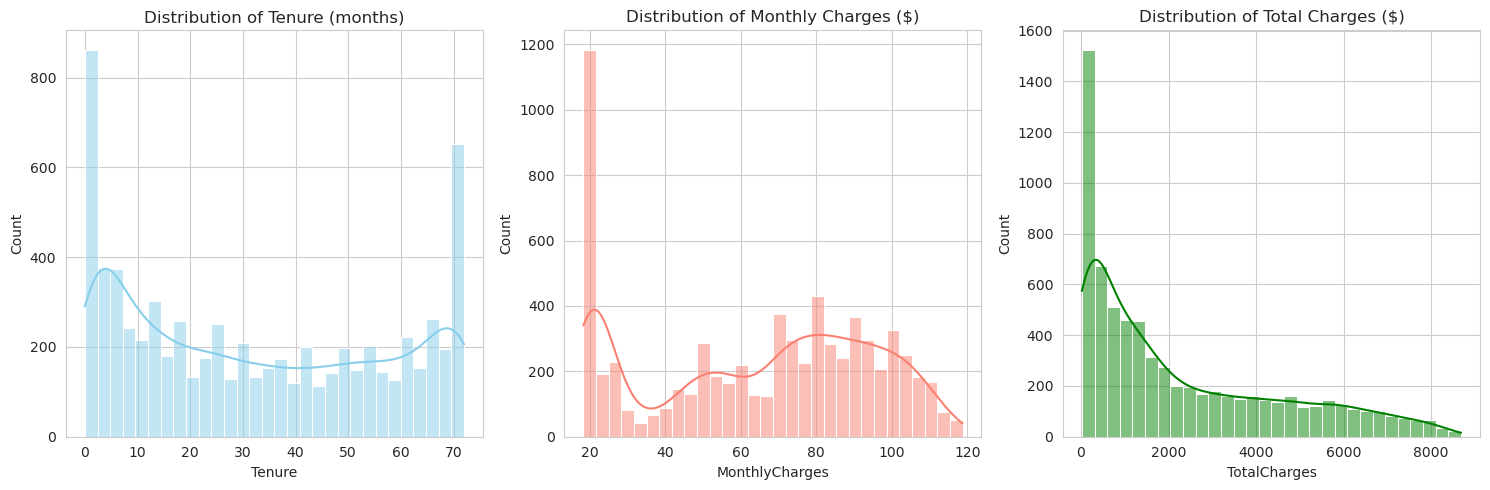

In [8]:
# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Tenure distribution
sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Tenure (months)')
axes[0].set_xlabel('Tenure')

# Plot 2: MonthlyCharges distribution
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Monthly Charges ($)')
axes[1].set_xlabel('MonthlyCharges')

# Plot 3: TotalCharges distribution (convert to numeric first)
# We'll handle the conversion properly later, but for EDA we force it
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
sns.histplot(total_charges_numeric.dropna(), bins=30, kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribution of Total Charges ($)')
axes[2].set_xlabel('TotalCharges')

plt.tight_layout()
plt.show()

Tenure and MonthlyCharges might be great predictors. TotalCharges is highly correlated with tenure × MonthlyCharges – we might engineer an interaction later.

## Visualization 2: Churn Rate by Contract Type (THE most important plot)

**Question**: Does the type of contract (Month-to-month, One year, Two year) dramatically affect churn?

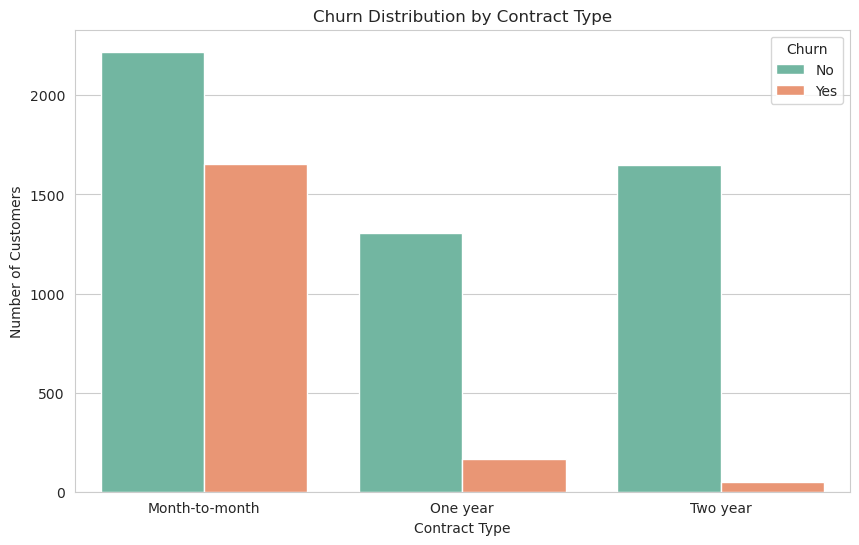

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [9]:
# Create a countplot with hue = Churn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

# Calculate the churn percentage per contract type
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print(contract_churn)

**Business insight**: The single most powerful action to reduce churn is to convert customers from month-to-month to annual contracts. This will be our strongest feature in the model.

## Visualization 3: Tenure vs Churn (Boxplot / Histogram)

**Question**: Do customers who churn have shorter or longer tenure?

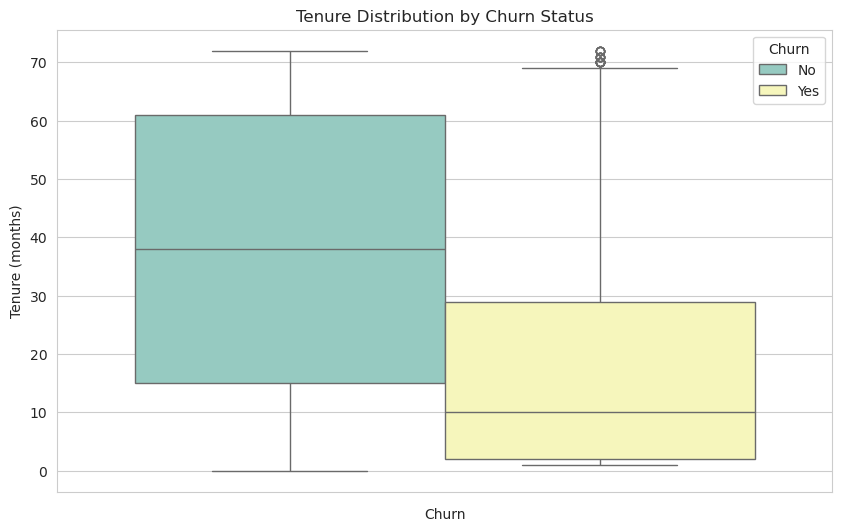

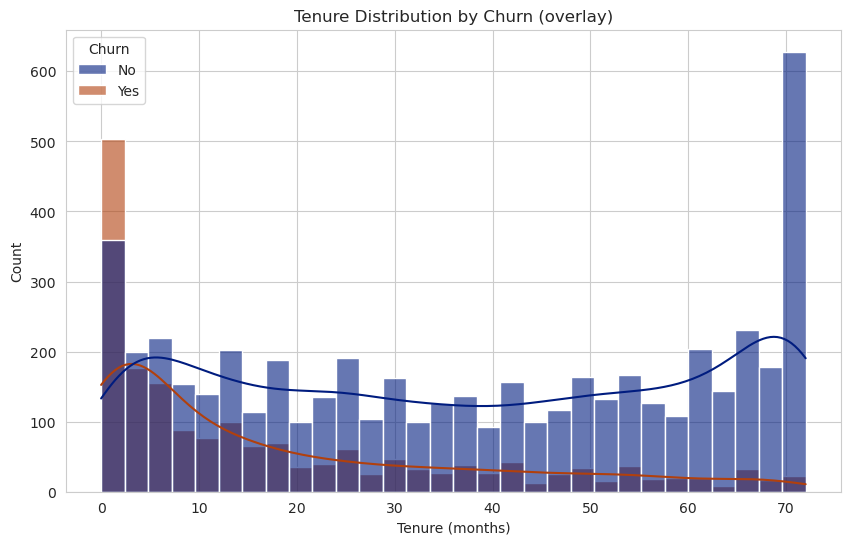

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, hue='Churn', y='tenure', palette='Set3')
plt.title('Tenure Distribution by Churn Status')
plt.ylabel('Tenure (months)')
plt.xlabel('Churn')
plt.show()

# Alternatively, overlay histograms
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30, palette='dark', alpha=0.6)
plt.title('Tenure Distribution by Churn (overlay)')
plt.xlabel('Tenure (months)')
plt.show()

**Business insight**: The first few months are critical. The company should focus retention efforts on new customers (e.g., welcome calls, onboarding support).

**Model implication**: Tenure will be a top predictor. We might create a feature like is_new_customer (tenure < 3 months).

## Visualization 4: MonthlyCharges vs Churn

**Question**: Are customers paying more likely to churn?

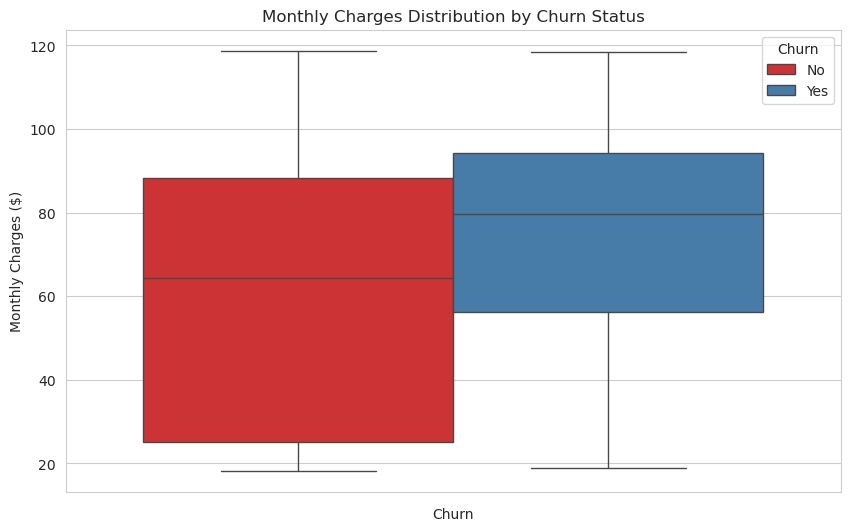

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, hue='Churn', y='MonthlyCharges', palette='Set1')
plt.title('Monthly Charges Distribution by Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.xlabel('Churn')
plt.show()

**Business insight**: High-paying customers are more price-sensitive. They might expect more value for money.

**Model implication**: MonthlyCharges is useful, but we may need to combine it with Contract type (e.g., high charges + month-to-month = highest risk).

## Visualization 5: Churn by InternetService and PaymentMethod

**Question**: Does the type of internet service or payment method influence churn?

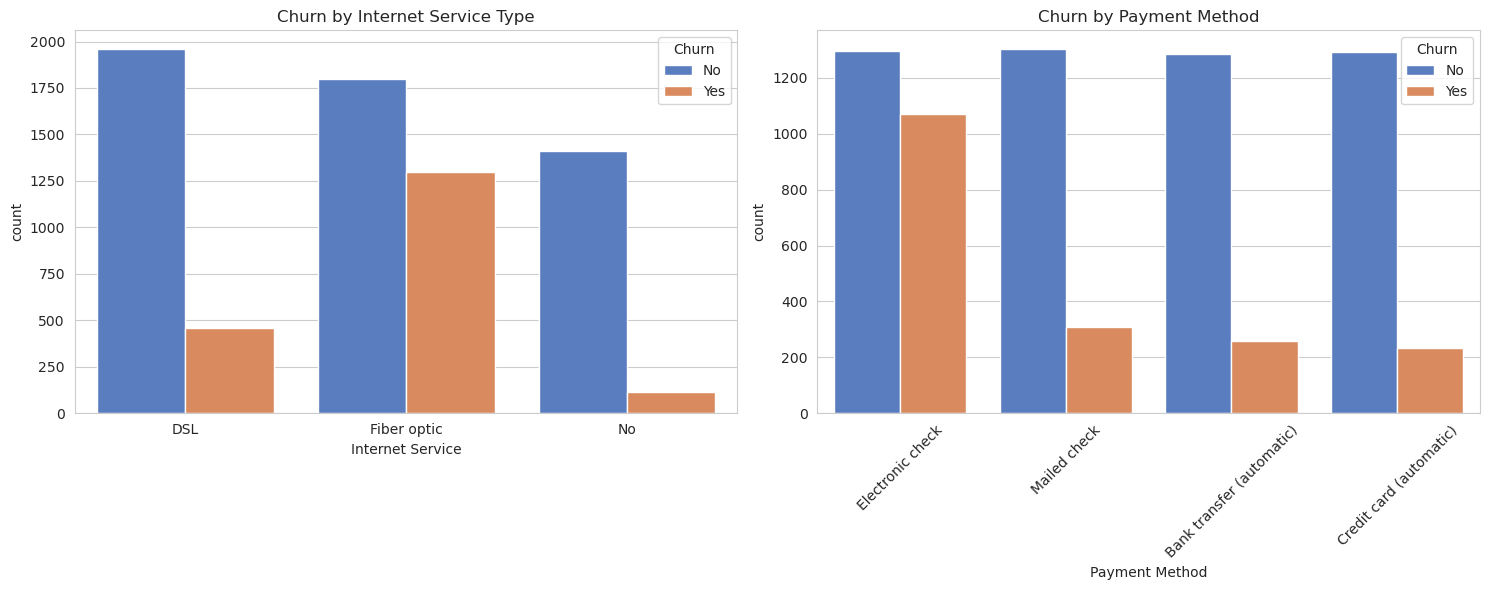

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


In [12]:
# Create a 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: InternetService vs Churn
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0], palette='muted')
axes[0].set_title('Churn by Internet Service Type')
axes[0].set_xlabel('Internet Service')

# Plot 2: PaymentMethod vs Churn
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[1], palette='muted')
axes[1].set_title('Churn by Payment Method')
axes[1].set_xlabel('Payment Method')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Calculate percentages for PaymentMethod
payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100
print(payment_churn)

**Business insight**: Encourage automatic payments (e.g., with small discounts) and address fiber optic service quality.

## Visualization 6: Correlation Heatmap for Numeric Features

**Question**: Are tenure, MonthlyCharges, and TotalCharges strongly correlated with each other?

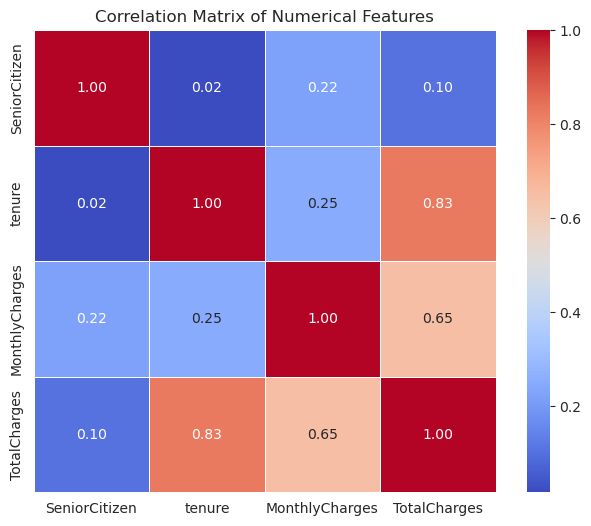

In [13]:
# Convert TotalCharges to numeric (for correlation matrix)
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

# Select numeric columns (including SeniorCitizen)
numeric_df = df_eda[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']]

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Interpretation**:
* `tenure` and `TotalCharges` are highly positively correlated (obvious – longer tenure = more total charges).
* `MonthlyCharges` and `TotalCharges` are moderately correlated.

In [14]:
# it's curios for me: the churn percentage for people with/without tech support
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index')

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


# 3rd phase: Data Preprocessing

## 3.1: Fix `TotalCharges` and `Drop customerID`

In [15]:
# 1. Convert TotalCharges from string to float (coerce errors to NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Why are there NaN values? Let's check the rows where TotalCharges is NaN
print("Rows with missing TotalCharges:")
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])

# 3. Fill NaN with 0 (these are brand-new customers with tenure 0,
# so TotalCharges = MonthlyCharges × tenure = $0, it's mathematically correct)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 4. Drop customerID – it's a random unique string, useless for prediction
df.drop('customerID', axis=1, inplace=True)

print(f"\nDataset shape after dropping customerID: {df.shape}")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].head())

Rows with missing TotalCharges:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN

Dataset shape after dropping customerID: (7043, 20)
   tenure  MonthlyCharges  TotalCharges
0       1           29.85         29.85
1      34           56.95       1889.50
2       2           53.85        108.15
3      45           42.30       1840.75
4       2           70.70        151.65


## 3.2: Separate Features (X) and Target (y)

In [16]:
# 1. Define target
y = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Define features (drop the target column)
X = df.drop('Churn', axis=1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True) * 100}")

Features shape: (7043, 19)
Target shape: (7043,)
Target distribution:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


## 3.3: Train‑Test Split (Important)

In [17]:
from sklearn.model_selection import train_test_split

# Stratify = keep the same churn percentage (26.5%) in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,          # 80% train, 20% test
    random_state=42,        # Reproducibility
    stratify=y              # Critical for imbalanced datasets
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean() * 100:.2f}%")
print(f"Test churn rate: {y_test.mean() * 100:.2f}%")

Train shape: (5634, 19)
Test shape: (1409, 19)
Train churn rate: 26.54%
Test churn rate: 26.54%


# 4th phase: Feature Engineering

## 4.1: Create New Features

In [18]:
# --- FEATURE ENGINEERING FUNCTION ---
# We write a function so we apply the exact same logic to train AND test
def engineer_features(df):
    """
    Adds new features to the Telco Churn DataFrame.
    """
    # Make a copy to avoid modifying the original slice
    df_new = df.copy()
    
    # --- FEATURE 1: Average Monthly Spend (Total Charges / Tenure) ---
    # Business logic: A customer who spends $100/month for 2 years vs 1 month.
    # High average spend indicates a premium user, which might increase or decrease churn.
    # We use .div() to handle division by zero gracefully.
    df_new['Avg_Monthly_Spend'] = df_new['TotalCharges'].div(df_new['tenure']).replace([float('inf'), -float('inf')], 0).fillna(0)
    
    # --- FEATURE 2: Tenure Groups (Categorical) ---
    # Business logic: New customers (0-6 months) are high-risk. Loyal customers (3+ years) are safe.
    # Binning continuous values helps tree models find non-linear patterns easily.
    bins = [0, 6, 12, 24, 72]
    labels = ['New (0-6m)', 'Recent (7-12m)', 'Regular (1-2y)', 'Loyal (2y+)']
    df_new['Tenure_Group'] = pd.cut(df_new['tenure'], bins=bins, labels=labels, right=False)
    
    # --- FEATURE 3: Total Services Subscribed ---
    # Business logic: The more services (security, backup, streaming) a customer has, 
    # the "stickier" they are. It's a switching cost proxy.
    # List of services columns (all categorical)
    service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    
    # Count how many of these services are NOT 'No' or 'No phone service'
    # We sum across columns for each row
    df_new['Service_Count'] = df_new[service_cols].apply(lambda row: (row != 'No').sum(), axis=1)
    # NOTE: This counts 'No phone service' as a valid service (since it's != 'No'), 
    # which is okay, but we can adjust if needed. For simplicity, we keep it.
    
    # --- FEATURE 4: Contract Tenure Ratio (Interaction) ---
    # Business logic: A month-to-month contract with 5 years tenure is rare.
    # This feature captures how "committed" the customer is relative to their contract.
    # We map Contract to numeric: Month-to-month = 1, One year = 12, Two year = 24.
    contract_mapping = {'Month-to-month': 1, 'One year': 12, 'Two year': 24}
    df_new['Contract_Tenure_Ratio'] = df_new['tenure'] / df_new['Contract'].map(contract_mapping)
    # If tenure = 0, ratio is 0. If tenure is 24 months and contract is 1 month, ratio = 24 (very risky).
    
    return df_new

# Apply the function to BOTH train and test
X_train_engineered = engineer_features(X_train)
X_test_engineered = engineer_features(X_test)

print("Original Train Columns:", X_train.shape[1])
print("New Train Columns:", X_train_engineered.shape[1])
print("\nNew features added:", set(X_train_engineered.columns) - set(X_train.columns))

Original Train Columns: 19
New Train Columns: 23

New features added: {'Tenure_Group', 'Avg_Monthly_Spend', 'Service_Count', 'Contract_Tenure_Ratio'}


## 4.2: Re-run Encoding & Scaling with the New Features

* **3.4: Separate Numeric and Categorical Columns (on Training Data Only)**
* **3.5: Encode Categorical Variables (One‑Hot Encoding)**
* **3.6: Scale Numerical Features (Standardization)**

In [26]:
# --- RE-DO SUB-STEP 4: Split columns again ---
# Numeric columns (including our new Avg_Monthly_Spend, Service_Count, Contract_Tenure_Ratio)
num_cols_new = X_train_engineered.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns (including our new Tenure_Group and existing text columns)
cat_cols_new = X_train_engineered.select_dtypes(include=['object', 'str', 'category']).columns.tolist()

print("Numerical features now:", num_cols_new)
print("Categorical features now:", cat_cols_new)

# --- RE-DO SUB-STEP 5: Encoding ---
X_train_encoded = pd.get_dummies(X_train_engineered, columns=cat_cols_new, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_engineered, columns=cat_cols_new, drop_first=True)

# ALIGN columns (Crucial!)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"Shape after encoding: Train={X_train_encoded.shape}, Test={X_test_encoded.shape}")

# --- RE-DO SUB-STEP 6: Scaling ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train_encoded.copy()
X_train_scaled[num_cols_new] = scaler.fit_transform(X_train_encoded[num_cols_new])

X_test_scaled = X_test_encoded.copy()
X_test_scaled[num_cols_new] = scaler.transform(X_test_encoded[num_cols_new])

print("Scaling complete!")
print(f"Final Train shape: {X_train_scaled.shape}")
print(f"Final Test shape: {X_test_scaled.shape}")

Numerical features now: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Avg_Monthly_Spend', 'Service_Count', 'Contract_Tenure_Ratio']
Categorical features now: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Tenure_Group']
Shape after encoding: Train=(5634, 36), Test=(1409, 36)
Scaling complete!
Final Train shape: (5634, 36)
Final Test shape: (1409, 36)


In [27]:
# Check if test set has any column that train set doesn't
missing_cols = set(X_test_scaled.columns) - set(X_train_scaled.columns)
extra_cols = set(X_train_scaled.columns) - set(X_test_scaled.columns)
print(f"Columns in test but not in train: {missing_cols}")
print(f"Columns in train but not in test: {len(extra_cols)}")

# Check dimensions
print(f"\nFinal train shape: {X_train_scaled.shape}")
print(f"Final test shape: {X_test_scaled.shape}")

Columns in test but not in train: set()
Columns in train but not in test: 0

Final train shape: (5634, 36)
Final test shape: (1409, 36)


In [28]:
# Check the mean of the new features in train vs test
new_feats = ['Avg_Monthly_Spend', 'Service_Count', 'Contract_Tenure_Ratio']
print("Train Means:")
print(X_train_scaled[new_feats].mean())
print("\nTest Means:")
print(X_test_scaled[new_feats].mean())

# Check if Tenure_Group encoding worked
tenure_cols = [col for col in X_train_scaled.columns if 'Tenure_Group' in col]
print(f"\nTenure group columns created: {len(tenure_cols)}")

Train Means:
Avg_Monthly_Spend        2.686290e-16
Service_Count           -1.059382e-16
Contract_Tenure_Ratio   -1.387286e-17
dtype: float64

Test Means:
Avg_Monthly_Spend       -0.029778
Service_Count           -0.043617
Contract_Tenure_Ratio   -0.020783
dtype: float64

Tenure group columns created: 3


# 5th phase: Handling Imbalanced Data

## 5.1: Import the Required Library

In [29]:
# Import SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

# Also import a handy metric for later
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## Step 5.2: Check the Current Imbalance Ratio (Baseline)

In [30]:
# Count the classes in the training set
print("Original training set class distribution:")
print(Counter(y_train))

# Calculate percentages
total = len(y_train)
churn_yes = sum(y_train)
churn_no = total - churn_yes
print(f"Churn = 0 (No): {churn_no} ({churn_no/total*100:.2f}%)")
print(f"Churn = 1 (Yes): {churn_yes} ({churn_yes/total*100:.2f}%)")

Original training set class distribution:
Counter({0: 4139, 1: 1495})
Churn = 0 (No): 4139 (73.46%)
Churn = 1 (Yes): 1495 (26.54%)


## 5.3: Apply SMOTE to the Training Set (ONLY!)

In [31]:
# Initialize SMOTE with a random seed for reproducibility
smote = SMOTE(random_state=42)

# Fit and transform ONLY the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Check the new distribution
print("Training set AFTER SMOTE:")
print(Counter(y_train_smote))

# Verify it's perfectly balanced
total_smote = len(y_train_smote)
churn_yes_smote = sum(y_train_smote)
churn_no_smote = total_smote - churn_yes_smote
print(f"Churn = 0 (No): {churn_no_smote} ({churn_no_smote/total_smote*100:.2f}%)")
print(f"Churn = 1 (Yes): {churn_yes_smote} ({churn_yes_smote/total_smote*100:.2f}%)")
print(f"Total samples: {total_smote} (was {total})")

Training set AFTER SMOTE:
Counter({0: 4139, 1: 4139})
Churn = 0 (No): 4139 (50.00%)
Churn = 1 (Yes): 4139 (50.00%)
Total samples: 8278 (was 5634)


In [32]:
# Check data types
print(X_train_scaled.dtypes.value_counts())
print("\nColumns with object dtype:")
print(X_train_scaled.select_dtypes(include=['object', 'str']).columns.tolist())

bool       29
float64     7
Name: count, dtype: int64

Columns with object dtype:
[]


## 5.4: Alternative Approach – Class Weights

In [33]:
# Calculate the class weights automatically
from sklearn.utils.class_weight import compute_class_weight

# Compute weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), weights))
print("Class weights (train):", class_weight_dict)

Class weights (train): {np.int64(0): np.float64(0.6805991785455424), np.int64(1): np.float64(1.8842809364548494)}


Interpretation: A mistake on a churner (class 1) is 1.88x more costly than a mistake on a non-churner (class 0).

## 5.5: Save Both Versions of Training Data

In [35]:
# Original (for Class Weights)
X_train_original = X_train_scaled.copy()
y_train_original = y_train.copy()

# SMOTE (for oversampling)
X_train_smote = X_train_smote
y_train_smote = y_train_smote

# Test set remains the same for both
X_test_final = X_test_scaled.copy()
y_test_final = y_test.copy()

print("✅ Both training versions ready!")
print(f"Original train shape: {X_train_original.shape}")
print(f"SMOTE train shape: {X_train_smote.shape}")
print(f"Test shape: {X_test_final.shape}")

✅ Both training versions ready!
Original train shape: (5634, 36)
SMOTE train shape: (8278, 36)
Test shape: (1409, 36)


## 5.6: Sanity Check – Visualize the Effect

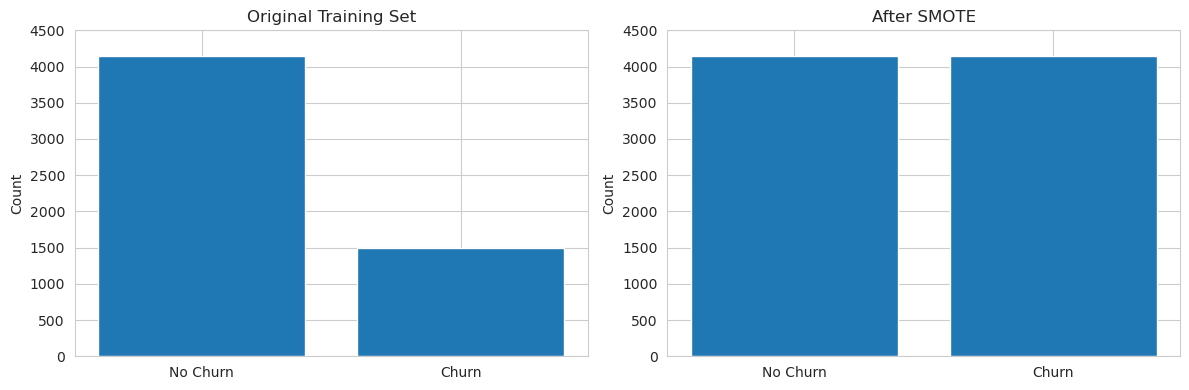

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Original training distribution
axes[0].bar(['No Churn', 'Churn'], [sum(y_train_original == 0), sum(y_train_original == 1)])
axes[0].set_title('Original Training Set')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 4500)

# Plot 2: SMOTE training distribution
axes[1].bar(['No Churn', 'Churn'], [sum(y_train_smote == 0), sum(y_train_smote == 1)])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, 4500)

plt.tight_layout()
plt.show()

# 6th phase: Model Building

In [42]:
# Import models and evaluation tools
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import pandas as pd

# 1. Logistic Regression (with class weights)
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

# 2. Random Forest (on SMOTE data)
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# 3. XGBoost (on SMOTE data)
xgb = XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

# Define a function to print evaluation metrics
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_true, y_proba):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

# Evaluate all models
evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb)


Model: Logistic Regression
Accuracy  : 0.7459
Precision : 0.5136
Recall    : 0.8102
F1 Score  : 0.6286
ROC-AUC   : 0.8481

Confusion Matrix:
[[748 287]
 [ 71 303]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409


Model: Random Forest
Accuracy  : 0.7658
Precision : 0.5547
Recall    : 0.5963
F1 Score  : 0.5747
ROC-AUC   : 0.8230

Confusion Matrix:
[[856 179]
 [151 223]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.55      0.60      0.57       374

    accuracy                           0.77      1409
   macro avg       0.70      0.71      0.71      1409
weighted avg       0.77      

**The clear winner is Logistic Regression.**

Logistic Regression catches 81% of churners, while Random Forest only catches 60%. That’s a massive 21% difference in saved customers. For a business with 1,000 customers, LR would save ~200 more customers than RF.

# 7th phase Feature Importance & Model Interpretation

In [54]:
# --- Logistic Regression Coefficients ---
# Get feature names and coefficients
feature_names = X_train_scaled.columns
coefs = lr.coef_[0]  # coefficients for the churn class (1)

# Create a DataFrame for easier sorting
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
})

# Sort by absolute value to see most influential features
coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values('abs_coef', ascending=False)


print("\n\n\n")
print()

In [56]:
# --- Logistic Regression Coefficients ---
# Get feature names and coefficients
feature_names = X_train_scaled.columns
coefs = lr.coef_[0]  # coefficients for the churn class (1)

# Create a DataFrame for easier sorting
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
})

# Sort by absolute value to see most influential features
coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values('abs_coef', ascending=False)

# Top 10 positive (increase churn) and top 10 negative (decrease churn)
top_positive = coef_df[coef_df['coefficient'] > 0].head(10)
top_negative = coef_df[coef_df['coefficient'] < 0].head(10)

print("Top 10 features that INCREASE churn probability:")
print(top_positive[['feature', 'coefficient']])

print("\nTop 10 features that DECREASE churn probability:")
print(top_negative[['feature', 'coefficient']])

Top 10 features that INCREASE churn probability:
                           feature  coefficient
13     InternetService_Fiber optic     1.240799
26             StreamingMovies_Yes     0.416255
24                 StreamingTV_Yes     0.394498
31  PaymentMethod_Electronic check     0.386170
29            PaperlessBilling_Yes     0.341479
12               MultipleLines_Yes     0.331252
3                     TotalCharges     0.163833
5                    Service_Count     0.069378
4                Avg_Monthly_Spend     0.061881
0                    SeniorCitizen     0.060302

Top 10 features that DECREASE churn probability:
                        feature  coefficient
28            Contract_Two year    -2.442112
27            Contract_One year    -1.469096
2                MonthlyCharges    -0.541677
1                        tenure    -0.523938
33  Tenure_Group_Recent (7-12m)    -0.460713
34  Tenure_Group_Regular (1-2y)    -0.415294
16           OnlineSecurity_Yes    -0.341717
6         Con

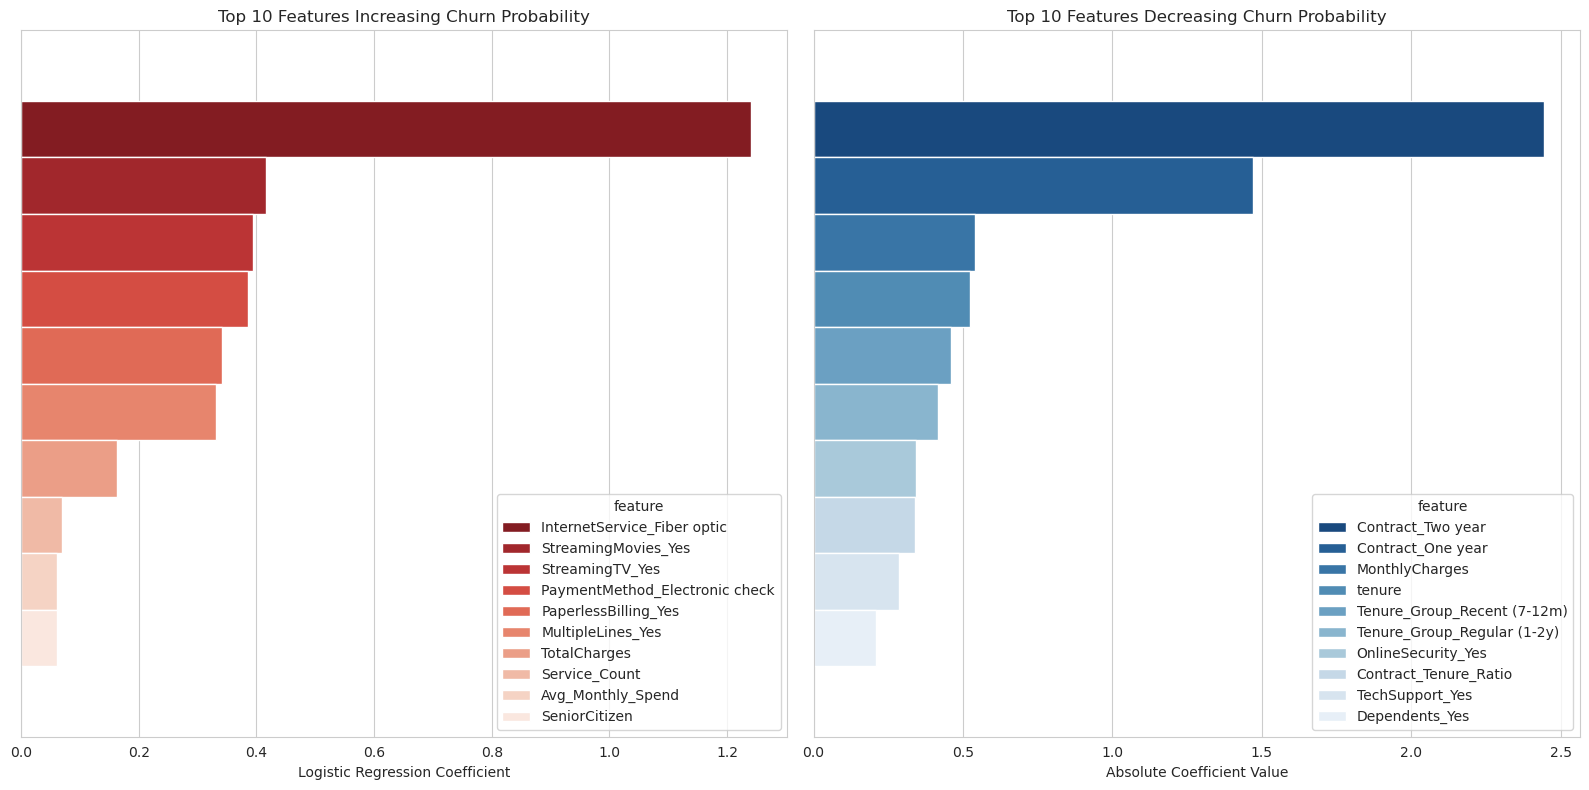

In [57]:
# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot positive coefficients
sns.barplot(data=top_positive, x='coefficient', hue='feature', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Features Increasing Churn Probability')
axes[0].set_xlabel('Logistic Regression Coefficient')

# Plot negative coefficients (absolute values for display)
top_negative_abs = top_negative.copy()
top_negative_abs['abs_coef'] = top_negative_abs['coefficient'].abs()
sns.barplot(data=top_negative_abs, x='abs_coef', hue='feature', ax=axes[1], palette='Blues_r')
axes[1].set_title('Top 10 Features Decreasing Churn Probability')
axes[1].set_xlabel('Absolute Coefficient Value')

plt.tight_layout()
plt.show()


Top 15 Random Forest Feature Importances:
                           feature  importance
1                           tenure    0.119264
3                     TotalCharges    0.112330
2                   MonthlyCharges    0.096401
4                Avg_Monthly_Spend    0.093938
6            Contract_Tenure_Ratio    0.088068
31  PaymentMethod_Electronic check    0.063676
5                    Service_Count    0.059140
28               Contract_Two year    0.040126
29            PaperlessBilling_Yes    0.036920
13     InternetService_Fiber optic    0.035557
7                      gender_Male    0.019285
27               Contract_One year    0.016521
12               MultipleLines_Yes    0.015147
8                      Partner_Yes    0.015041
35        Tenure_Group_Loyal (2y+)    0.015021


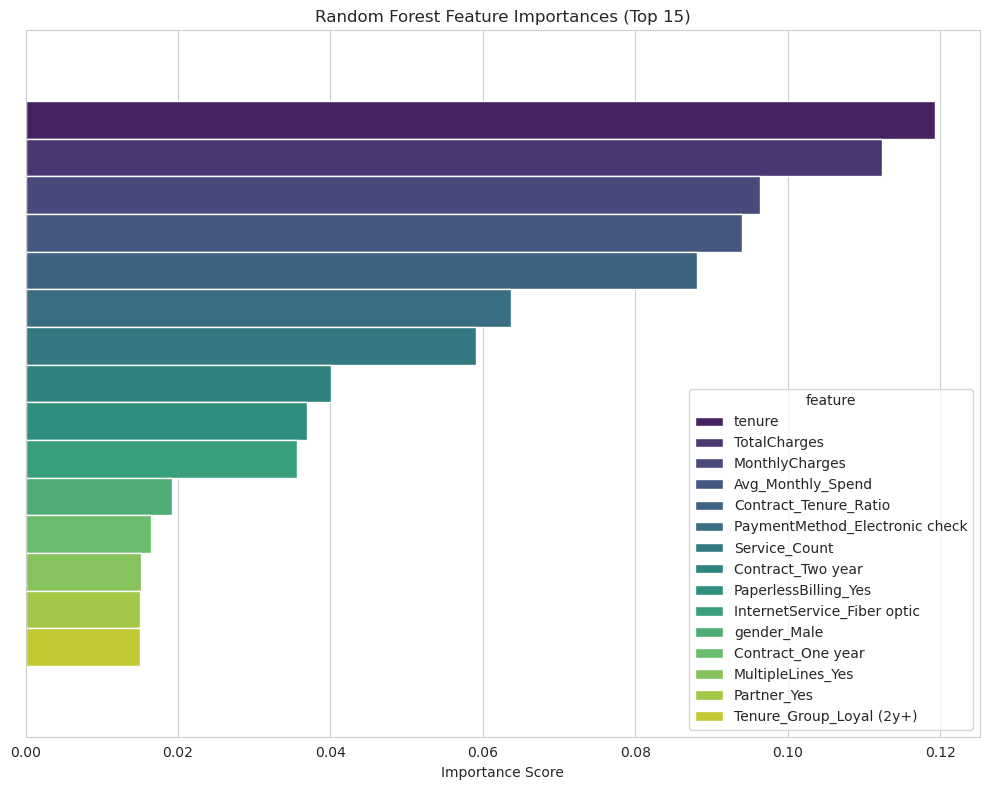

In [59]:
# --- Random Forest Feature Importances ---
rf_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

print("\nTop 15 Random Forest Feature Importances:")
print(rf_importances)

# Plot RF importances
plt.figure(figsize=(10, 8))
sns.barplot(data=rf_importances, x='importance', hue='feature', palette='viridis')
plt.title('Random Forest Feature Importances (Top 15)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# 8th phase: Streamlit Deployment

In [60]:
import joblib

# Save the Logistic Regression model
joblib.dump(lr, 'churn_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the training columns (for aligning new data)
training_columns = X_train_scaled.columns.tolist()
joblib.dump(training_columns, 'training_columns.pkl')

print("Model, scaler, and training columns saved successfully")

Model, scaler, and training columns saved successfully
